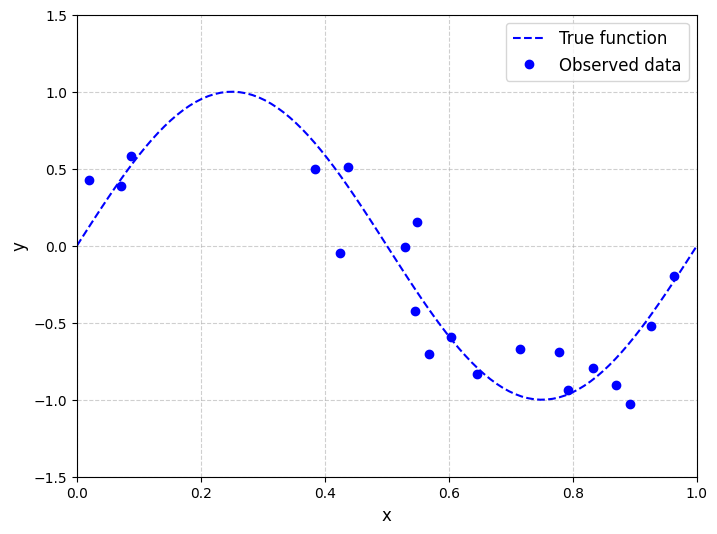

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the true sine function
def true_function(x):
    """Computes the true sine function value."""
    return np.sin(2 * np.pi * x)

# 2. Generate data for plotting the true function
# Create a hundred points from 0 to 1 for a smooth curve.
x_true = np.linspace(0, 1, 100)
y_true = true_function(x_true)

# 3. Generate noisy toy data
# Set a seed for reproducibility of random sampling.
np.random.seed(0)
num_samples = 20
# Sample random points from the domain [0, 1].
x_observed = np.sort(np.random.rand(num_samples))
# Evaluate the true function at the sampled points and add Gaussian noise.
noise = np.random.normal(loc=0, scale=0.2, size=num_samples)
y_observed = true_function(x_observed) + noise

# 4. Create the plot
plt.figure(figsize=(8, 6))

# Plot the true function as a red dashed line.
plt.plot(x_true, y_true, 'b--', label='True function')

# Plot the observed data as blue scatter points.
plt.plot(x_observed, y_observed, 'bo', label='Observed data')

# 5. Add labels, legend, and grid for better readability.
plt.xlabel('x', fontsize='large')
plt.ylabel('y', fontsize='large')
plt.legend(fontsize='large')
plt.grid(True, linestyle='--', alpha=0.6)

# Set plot limits.
plt.xlim(0, 1)
plt.ylim(-1.5, 1.5)

# Save the plot to a file.
plt.savefig('sine_function_with_noisy_data.png')

# plt.show() # Use this to display the plot in a window if running locally.


--- Manually Set Hyperparameters ---
Kernel lengthscale: 0.3000
Kernel outputscale: 0.8000
Assumed noise variance: 0.0400
----------------------------------


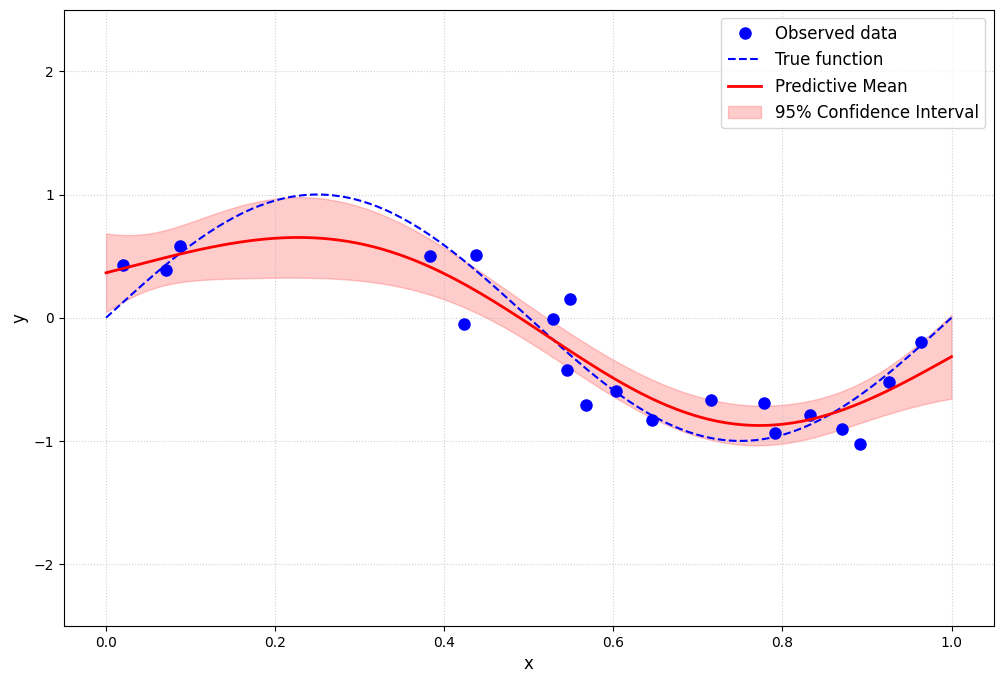

In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# --- General Setup ---
# Set random seed for reproducibility to match the user's request
np.random.seed(0)


# =============================================================================
# 1. Generate Training Data (Using the user's provided logic)
# =============================================================================
# Define the true sine function
def true_function(x):
    """Computes the true sine function value."""
    return np.sin(2 * np.pi * x)

# Generate noisy toy data exactly as specified
num_samples = 20
# Sample random points from the domain [0, 1]
train_X_np = np.sort(np.random.rand(num_samples)).reshape(-1, 1)
# Evaluate the true function and add Gaussian noise with scale=0.2
noise_vec = np.random.normal(loc=0, scale=0.2, size=num_samples)
train_Y_np = true_function(train_X_np).flatten() + noise_vec
train_Y_np = train_Y_np.reshape(-1, 1)


# =============================================================================
# 2. Scratch Implementation of Gaussian Process Regression
# =============================================================================

def rbf_kernel(X1, X2, lengthscale, outputscale):
    """
    Computes the Radial Basis Function (RBF) kernel between two sets of points.
    """
    sq_dist = cdist(X1, X2, 'sqeuclidean')
    return outputscale * np.exp(-0.5 * sq_dist / lengthscale**2)

class GaussianProcessRegressor:
    """
    A simple Gaussian Process Regressor implemented from scratch.
    """
    def __init__(self, lengthscale, outputscale, noise):
        # Manually set hyperparameters since BoTorch is removed
        self.lengthscale = lengthscale
        self.outputscale = outputscale
        self.noise = noise
        self.X_train = None
        self.y_train = None
        self.K_inv = None
        self.alpha = None

    def fit(self, X, y):
        """
        Fits the GP model to the training data.
        """
        self.X_train = X
        self.y_train = y
        K = rbf_kernel(X, X, self.lengthscale, self.outputscale)
        K_noisy = K + self.noise * np.eye(len(X))
        self.K_inv = np.linalg.inv(K_noisy)
        self.alpha = self.K_inv @ y
        
    def predict(self, X_test):
        """
        Makes predictions for new data points X_test.
        """
        if self.X_train is None:
            raise RuntimeError("The model has not been fitted yet. Call fit() first.")
        K_s = rbf_kernel(X_test, self.X_train, self.lengthscale, self.outputscale)
        K_ss = rbf_kernel(X_test, X_test, self.lengthscale, self.outputscale)
        mean = K_s @ self.alpha
        v = self.K_inv @ K_s.T
        covariance = K_ss - K_s @ v
        variance = np.diag(covariance)
        return mean.flatten(), variance.flatten()

# --- Manually Define Hyperparameters ---
# Since we removed BoTorch, we need to set these values ourselves.
# These values are chosen to be reasonable for this specific dataset.
# In a real application, you would use techniques like cross-validation
# or marginal likelihood optimization to find these.
lengthscale = 0.3
outputscale = 0.8
noise = 0.04 # This is sigma^2, so sqrt(0.04) = 0.2 which is our noise std dev

print("\n--- Manually Set Hyperparameters ---")
print(f"Kernel lengthscale: {lengthscale:.4f}")
print(f"Kernel outputscale: {outputscale:.4f}")
print(f"Assumed noise variance: {noise:.4f}")
print("----------------------------------")


# Instantiate and fit the scratch model
gp_scratch = GaussianProcessRegressor(lengthscale=lengthscale, outputscale=outputscale, noise=noise)
gp_scratch.fit(train_X_np, train_Y_np)


# =============================================================================
# 3. Make Predictions
# =============================================================================
# Define test points
test_X_np = np.linspace(0, 1, 200).reshape(-1, 1)

# --- Scratch Predictions ---
mean_scratch, variance_scratch = gp_scratch.predict(test_X_np)
std_dev_scratch = np.sqrt(variance_scratch)
lower_scratch = mean_scratch - 1.96 * std_dev_scratch
upper_scratch = mean_scratch + 1.96 * std_dev_scratch


# =============================================================================
# 4. Plot the Results
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot Observed Data and True Function
ax.plot(train_X_np, train_Y_np, 'bo', label='Observed data', markersize=8)
ax.plot(test_X_np, true_function(test_X_np), 'b--', label='True function')

# Plot Scratch GP results (in red)
ax.plot(test_X_np, mean_scratch, 'r-', label='Predictive Mean', linewidth=2)
ax.fill_between(test_X_np.squeeze(), lower_scratch, upper_scratch,
                alpha=0.2, color='r', label='95% Confidence Interval')


# Final Plotting Adjustments
ax.set_ylim([-2.5, 2.5])
ax.legend(loc='upper right', fontsize='large')
# ax.set_title("Gaussian Process Regression (Scratch Implementation)")
ax.set_xlabel("x", fontsize='large')
ax.set_ylabel("y", fontsize='large')
ax.grid(True, linestyle=':', alpha=0.6)
plt.show()


/tmp/ipykernel_256491/1602572220.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  pdf = (np.math.gamma((df + 1) / 2) / (np.sqrt(df * np.pi) * np.math.gamma(df / 2))) * \


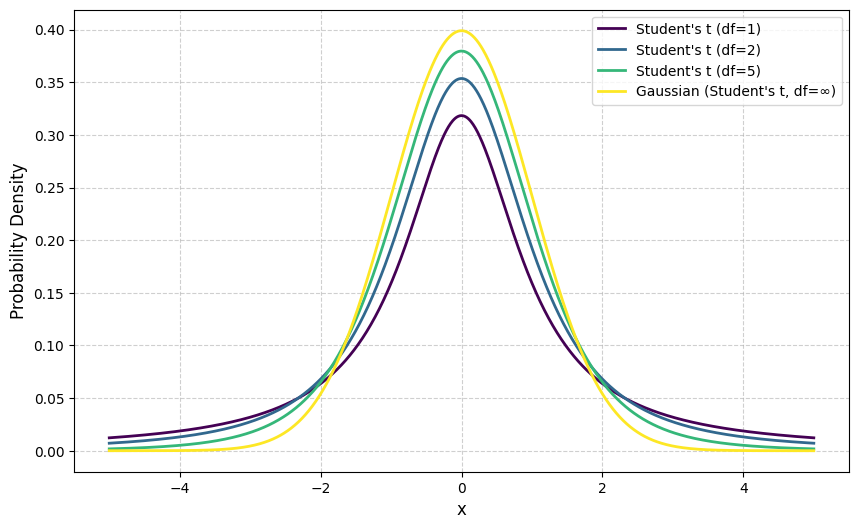

In [23]:
import matplotlib as mpl

# visualization of gaussian distribution and student-t distributions of different degrees of freedom
x = np.linspace(-5, 5, 1000)
mu = 0
sigma = 1
degrees_of_freedom = [1, 2, 5, np.inf]

# Use the 'viridis' colormap for gradation, including Gaussian as last color
cmap = plt.get_cmap('viridis')
colors = [cmap(i / (len(degrees_of_freedom)-1)) for i in range(len(degrees_of_freedom))]

plt.figure(figsize=(10, 6))

for idx, df in enumerate(degrees_of_freedom):
    if np.isinf(df):
        # Gaussian distribution as t with nu=inf
        pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        label = "Gaussian (Student's t, df=∞)"
    else:
        pdf = (np.math.gamma((df + 1) / 2) / (np.sqrt(df * np.pi) * np.math.gamma(df / 2))) * \
              (1 + (x ** 2) / df) ** (-(df + 1) / 2)
        label = f"Student's t (df={df})"
    plt.plot(x, pdf, label=label, color=colors[idx], linewidth=2)

plt.xlabel('x', fontsize='large')
plt.ylabel('Probability Density', fontsize='large')
# plt.title('Gaussian and Student\'s t-Distributions', fontsize='large')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()